**Import Libraries**

In [1]:
import pandas as pd
from mlxtend.preprocessing import TransactionEncoder
from mlxtend.frequent_patterns import apriori, association_rules

**Load the Dataset**

In [4]:
df = pd.read_csv('Groceries_dataset.csv')

# Display first 5 rows
df.head()

,Member_number,Date,itemDescription
0,1808,21-07-2015,tropical fruit
1,2552,05-01-2015,whole milk
2,2300,19-09-2015,pip fruit
3,1187,12-12-2015,other vegetables
4,3037,01-02-2015,whole milk


**create transactions**

In [11]:
# Create a transaction ID using Member_number and Date
df['Transaction'] = df['Member_number'].astype(str) + '_' + df['Date'].astype(str)

# Group items by transaction
transactions = df.groupby('Transaction')['itemDescription'].apply(list).tolist()

# Display first 5 transactions
transactions[:5]

[['sausage', 'whole milk', 'semi-finished bread', 'yogurt'],
 ['whole milk', 'pastry', 'salty snack'],
 ['canned beer', 'misc. beverages'],
 ['sausage', 'hygiene articles'],
 ['soda', 'pickled vegetables']]

**Convert Transactions to Basket Format**

In [12]:
# Convert transactions into one-hot encoded format
te = TransactionEncoder()
te_array = te.fit(transactions).transform(transactions)

basket = pd.DataFrame(te_array, columns=te.columns_)

# Display basket data
basket.head()

,Instant food products,UHT-milk,abrasive cleaner,artif. sweetener,baby cosmetics,bags,baking powder,bathroom cleaner,beef,berries,...,turkey,vinegar,waffles,whipped/sour cream,whisky,white bread,white wine,whole milk,yogurt,zwieback
0,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,True,True,False
1,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,True,False,False
2,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False


**Find Frequent Itemsets (Apriori Algorithm)**

In [13]:
# Find frequently purchased item combinations
frequent_itemsets = apriori(basket, min_support=0.01, use_colnames=True)

# Sort by support
frequent_itemsets = frequent_itemsets.sort_values(by='support', ascending=False)

# Display top itemsets
frequent_itemsets.head(10)

,support,itemsets
62,0.157923,frozenset({whole milk})
40,0.122101,frozenset({other vegetables})
46,0.110005,frozenset({rolls/buns})
52,0.097106,frozenset({soda})
63,0.085879,frozenset({yogurt})
47,0.069572,frozenset({root vegetables})
57,0.067767,frozenset({tropical fruit})
5,0.060683,frozenset({bottled water})
49,0.060349,frozenset({sausage})
15,0.053131,frozenset({citrus fruit})


**Generate Association Rules**

In [14]:
# Generate association rules
rules = association_rules(frequent_itemsets, metric='lift', min_threshold=1)

# Sort rules by lift
rules = rules.sort_values(by='lift', ascending=False)

# Display important columns
rules[['antecedents', 'consequents', 'support', 'confidence', 'lift']].head(10)

,antecedents,consequents,support,confidence,lift


**Show Top 10 Rules**

In [15]:
top_rules = rules[['antecedents', 'consequents', 'support', 'confidence', 'lift']].head(10)
top_rules

,antecedents,consequents,support,confidence,lift


**(Optional) Visualize the Most Frequent Items**

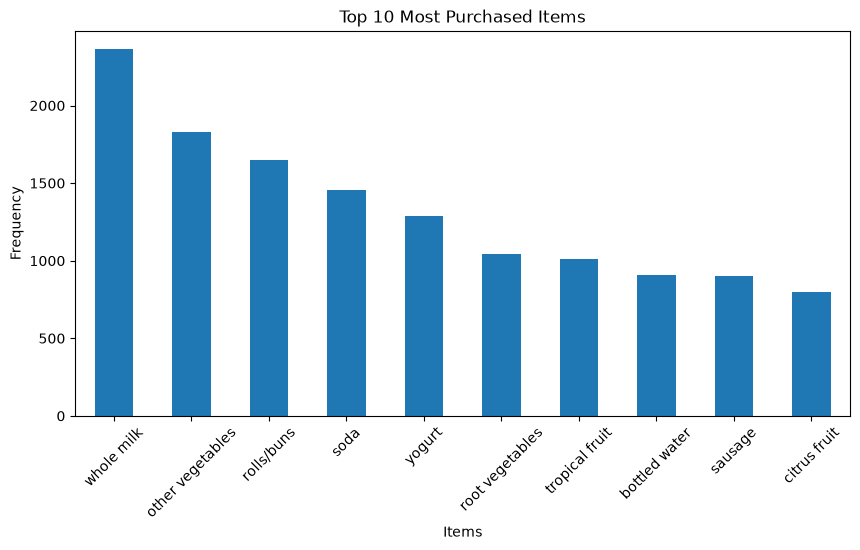

In [16]:
import matplotlib.pyplot as plt

# Count item frequency
item_counts = basket.sum().sort_values(ascending=False).head(10)

# Plot
plt.figure(figsize=(10,5))
item_counts.plot(kind='bar')
plt.title('Top 10 Most Purchased Items')
plt.xlabel('Items')
plt.ylabel('Frequency')
plt.xticks(rotation=45)
plt.show()